<a href="https://colab.research.google.com/github/JonathanDLCH/Crypto_DataAnalysis/blob/main/Stock_Market_API_part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 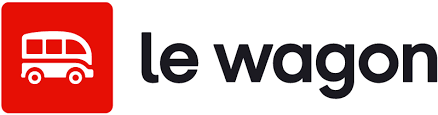

# Stock Market API - Part 2: Comparando acciones GAFA

En este ejercicio vamos a comparar la evolución diaria de las acciones **GAFA** (Google, Apple, Meta, Amazon) durante 2025.

Este notebook asume que ya completaste la **Part 1**, donde aprendiste a:
- Hacer llamadas a la API de [Massive](https://massive.com/)
- Convertir la respuesta JSON en un DataFrame de pandas
- Convertir timestamps, establecer índices y renombrar columnas

**Objetivos de este notebook:**
1. Obtener precios de cierre **diarios** de 4 acciones desde la API
2. Refactorizar código repetitivo con un `for` loop
3. Combinar DataFrames con `pd.concat()`
4. Analizar retornos, correlación y medias móviles (SMA)
5. Crear visualizaciones interactivas con **Plotly Express**

---

## Configuración

Comienza con los imports necesarios y tu API key:

In [1]:
import requests
import pandas as pd
import plotly.express as px

In [2]:
# TODO: Replace with your API key
API_KEY = "QCmF4Sr_X_nape8GPCl8JZ2vF9PBAI2c"

---

## Obteniendo datos de un ticker (GOOGL)

Vamos a empezar obteniendo los datos de **un solo ticker** (GOOGL) paso a paso. Luego refactorizaremos el código para los 4 tickers.

El endpoint de Massive para datos **diarios** es:

```
https://api.massive.com/v2/aggs/ticker/{TICKER}/range/1/day/2025-01-01/2025-12-31?apiKey={API_KEY}
```

**Nota:** A diferencia de la Part 1 donde usamos datos mensuales (`/range/1/month/`), aquí usamos datos **diarios** (`/range/1/day/`) para tener más puntos de datos (~250 días de trading).

Para GOOGL necesitas:
1. Hacer la llamada GET a la API
2. Crear un DataFrame con los resultados (`pd.DataFrame(data['results'])`)
3. Convertir el timestamp `t` a datetime (`pd.to_datetime(unit='ms')`)
4. Establecer la fecha como índice y quedarte solo con la columna de cierre `c`
5. Renombrar la columna `c` al nombre del ticker

<details><summary markdown='span'>Solución</summary>

```python
# Fetch daily data for GOOGL
url = f"https://api.massive.com/v2/aggs/ticker/GOOGL/range/1/day/2025-01-01/2025-12-31?apiKey={API_KEY}"
googl_data = requests.get(url).json()

# Create DataFrame from API response
googl_df = pd.DataFrame(googl_data['results'])

# Convert millisecond timestamp to datetime
googl_df['date'] = pd.to_datetime(googl_df['t'], unit='ms')

# Set date as index and keep only the close price column
googl_df = googl_df.set_index('date')[['c']]

# Rename column to ticker symbol
googl_df = googl_df.rename(columns={'c': 'GOOGL'})
```
</details>

In [3]:
# TODO: Fetch GOOGL daily data from Massive API for 2025
TICKER = "GOOGL"
url = f"https://api.massive.com/v2/aggs/ticker/{TICKER}/range/1/day/2025-01-01/2025-12-31?apiKey={API_KEY}"
# TODO: Create a DataFrame from the JSON response
api_data = requests.get(url).json()
df = pd.DataFrame(api_data['results'])
# TODO: Convert the timestamp column 't' to datetime
df['date'] = pd.to_datetime(df['t'], unit='ms')
# TODO: Set 'date' as index and keep only the close price column 'c'
df.set_index('date', inplace=True)
df = df[['c']]
# TODO: Rename the column 'c' to 'GOOGL'
df = df.rename(columns={'c': 'GOOGL'})

In [ ]:
# TODO: Display the first rows to verify your DataFrame
df.head()

,GOOGL
date,
2025-01-02 05:00:00,189.43
2025-01-03 05:00:00,191.79
2025-01-06 05:00:00,196.87
2025-01-07 05:00:00,195.49
2025-01-08 05:00:00,193.95


---

## Refactorizando con un `for` loop

Acabas de escribir el código para obtener los datos de GOOGL. Para obtener AAPL, META y AMZN, podrías copiar y pegar el mismo código 3 veces más... pero eso viola el principio **DRY** (Don't Repeat Yourself).

En su lugar, vamos a crear una lista de tickers y usar un `for` loop que repita los mismos pasos para cada uno. Almacena cada DataFrame resultante en una **lista** para luego combinarlos.

<details><summary markdown='span'>Solución</summary>

```python
tickers = ['GOOGL', 'AAPL', 'META', 'AMZN']
dfs = []

for ticker in tickers:
    # Build the API URL for each ticker
    url = f"https://api.massive.com/v2/aggs/ticker/{ticker}/range/1/day/2025-01-01/2025-12-31?apiKey={API_KEY}"
    data = requests.get(url).json()

    # Create DataFrame and process
    df = pd.DataFrame(data['results'])
    df['date'] = pd.to_datetime(df['t'], unit='ms')
    df = df.set_index('date')[['c']]
    df = df.rename(columns={'c': ticker})

    dfs.append(df)
```
</details>

In [4]:
# TODO: Create a list of tickers ['GOOGL', 'AAPL', 'META', 'AMZN']
tickers = ['GOOGL', 'AAPL', 'META', 'AMZN']
dfs = []
# TODO: Loop through each ticker, fetch data, and store DataFrames in a list
try:
  for ticker in tickers:
    url = f"https://api.massive.com/v2/aggs/ticker/{ticker}/range/1/day/2025-01-01/2025-12-31?apiKey={API_KEY}"
    print(url)
    api_data = requests.get(url).json()
    df = pd.DataFrame(api_data['results'])
    df['date'] = pd.to_datetime(df['t'], unit='ms')
    df.set_index('date', inplace=True)
    df = df[['c']]
    df = df.rename(columns={'c': ticker})
    dfs.append(df)
except (ValueError, TypeError):
  print("Error:"+ValueError)

https://api.massive.com/v2/aggs/ticker/GOOGL/range/1/day/2025-01-01/2025-12-31?apiKey=QCmF4Sr_X_nape8GPCl8JZ2vF9PBAI2c
https://api.massive.com/v2/aggs/ticker/AAPL/range/1/day/2025-01-01/2025-12-31?apiKey=QCmF4Sr_X_nape8GPCl8JZ2vF9PBAI2c
https://api.massive.com/v2/aggs/ticker/META/range/1/day/2025-01-01/2025-12-31?apiKey=QCmF4Sr_X_nape8GPCl8JZ2vF9PBAI2c
https://api.massive.com/v2/aggs/ticker/AMZN/range/1/day/2025-01-01/2025-12-31?apiKey=QCmF4Sr_X_nape8GPCl8JZ2vF9PBAI2c


In [5]:
dfs

[                      GOOGL
 date                       
 2025-01-02 05:00:00  189.43
 2025-01-03 05:00:00  191.79
 2025-01-06 05:00:00  196.87
 2025-01-07 05:00:00  195.49
 2025-01-08 05:00:00  193.95
 ...                     ...
 2025-12-24 05:00:00  314.09
 2025-12-26 05:00:00  313.51
 2025-12-29 05:00:00  313.56
 2025-12-30 05:00:00  313.85
 2025-12-31 05:00:00  313.00
 
 [250 rows x 1 columns],
                        AAPL
 date                       
 2025-01-02 05:00:00  243.85
 2025-01-03 05:00:00  243.36
 2025-01-06 05:00:00  245.00
 2025-01-07 05:00:00  242.21
 2025-01-08 05:00:00  242.70
 ...                     ...
 2025-12-24 05:00:00  273.81
 2025-12-26 05:00:00  273.40
 2025-12-29 05:00:00  273.76
 2025-12-30 05:00:00  273.08
 2025-12-31 05:00:00  271.86
 
 [250 rows x 1 columns],
                        META
 date                       
 2025-01-02 05:00:00  599.24
 2025-01-03 05:00:00  604.63
 2025-01-06 05:00:00  630.20
 2025-01-07 05:00:00  617.89
 2025-01-08 05:00:

---

## Combinando DataFrames con `pd.concat()`

Ahora tienes una lista con 4 DataFrames (uno por ticker). Para analizarlos juntos, necesitas combinarlos en un solo DataFrame.

Como todos comparten el mismo índice (fechas), usa [`pd.concat()`](https://pandas.pydata.org/docs/reference/api/pandas.concat.html) con `axis=1` para unirlos **por columnas**.

<details><summary markdown='span'>Solución</summary>

```python
gafa_df = pd.concat(dfs, axis=1)
gafa_df.head()
```
</details>

In [6]:
# TODO: Combine all DataFrames using pd.concat with axis=1
gafa_df = pd.concat(dfs, axis=1)

In [7]:
# TODO: Display the first rows of the combined DataFrame
gafa_df.iloc[:1]

,GOOGL,AAPL,META,AMZN
date,,,,
2025-01-02 05:00:00,189.43,243.85,599.24,220.22


---

## Explorando el DataFrame combinado

Antes de visualizar, es buena práctica explorar los datos. Responde estas preguntas:

1. **¿Cuáles son las estadísticas básicas?** → [`describe()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html)
2. **¿Qué tipos de datos tiene cada columna?** → [`.dtypes`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dtypes.html)
3. **¿Hay valores faltantes?** → [`.isna().sum()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isna.html)

In [8]:
# TODO: Use .describe() to see basic statistics
gafa_df.describe()

,GOOGL,AAPL,META,AMZN
count,250.000000,250.000000,250.000000,250.000000
mean,210.890560,232.240520,669.569540,217.672800
std,51.304804,26.468193,68.687114,17.096192
min,144.700000,172.420000,484.660000,167.320000
25%,170.590000,210.050000,619.095000,208.022500
50%,192.375000,230.005000,668.165000,222.120000
75%,246.990000,254.332500,720.452500,229.635000
max,323.440000,286.190000,790.000000,254.000000


In [9]:
# TODO: Check data types with .dtypes
gafa_df.dtypes

,0
GOOGL,float64
AAPL,float64
META,float64
AMZN,float64


In [10]:
# TODO: Check for missing values with .isna().sum()
gafa_df.isna().sum()

,0
GOOGL,0
AAPL,0
META,0
AMZN,0


---

## Visualización 1: Precios de cierre — [`px.line`](https://plotly.com/python-api-reference/generated/plotly.express.line)

Vamos a crear nuestro primer gráfico interactivo con [Plotly Express](https://plotly.com/python/plotly-express/). Un **line chart** es ideal para comparar la evolución temporal de las 4 acciones.

<details><summary markdown='span'>Solución</summary>

```python
# px.line: Creates an interactive line chart from a DataFrame
# - gafa_df: DataFrame where index=dates, columns=ticker prices
# - title: Text displayed above the chart
# - labels: Dict to rename default axis labels ('value' and 'variable')
# - template: Visual theme ('plotly_white' = clean white background)
fig = px.line(
    gafa_df,
    title='GAFA - Daily Closing Prices 2025',
    labels={'value': 'Price (USD)', 'variable': 'Ticker', 'date': 'Date'},
    template='plotly_white'
)
fig.show()
```
</details>

In [11]:
# TODO: Create a line chart with px.line() showing all 4 stocks
# Hint: pass gafa_df directly, use title, labels, and template parameters
fig = px.line(
    gafa_df,
    title='GAFA - Daily Closing Prices',
    labels={'value': 'Price (USD)', 'variable': 'Ticker', 'date': 'Date'},
    template='plotly_white'
    )
fig.show()

---

## Retornos diarios con `.pct_change()`

En finanzas, los **retornos porcentuales** son más informativos que los precios absolutos. Un retorno te dice cuánto subió o bajó una acción en un día, en porcentaje.

El método [`.pct_change()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.pct_change.html) calcula el cambio porcentual entre cada fila y la anterior:

```
retorno = (precio_hoy - precio_ayer) / precio_ayer
```

La primera fila será `NaN` (no hay día anterior), así que la eliminamos con [`.dropna()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html).

<details><summary markdown='span'>Solución</summary>

```python
# Calculate daily percentage returns for all tickers
# .pct_change() computes (current - previous) / previous
# .dropna() removes the first row which is NaN (no previous day)
returns = gafa_df.pct_change().dropna()
returns.head()
```
</details>

In [12]:
# TODO: Calculate daily returns using .pct_change() and remove NaN rows with .dropna()
returns = gafa_df.pct_change().dropna()
returns.head()

,GOOGL,AAPL,META,AMZN
date,,,,
2025-01-03 05:00:00,0.012458,-0.002009,0.008995,0.018027
2025-01-06 05:00:00,0.026487,0.006739,0.042290,0.015255
2025-01-07 05:00:00,-0.007010,-0.011388,-0.019533,-0.024164
2025-01-08 05:00:00,-0.007878,0.002023,-0.011604,0.000090
2025-01-10 05:00:00,-0.009848,-0.024104,0.008416,-0.014361


---

## Visualización 2: Retornos diarios — [`px.bar`](https://plotly.com/python-api-reference/generated/plotly.express.bar)

Un gráfico de barras de los retornos diarios permite ver la **volatilidad** de una acción — qué tan grandes y frecuentes son los movimientos positivos y negativos.

Vamos a graficar los retornos de **GOOGL** coloreados según sean positivos (verde) o negativos (rojo).

Para esto, crea una nueva columna que indique la dirección del retorno. Usa [`.loc`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.loc.html) con indexación booleana para asignar valores condicionalmente.

<details><summary markdown='span'>Solución</summary>

```python
# Prepare data: extract GOOGL returns and reset index to get 'date' as column
googl_returns = returns[['GOOGL']].reset_index()

# Use .loc with boolean indexing to classify returns as Positive or Negative
googl_returns['Direction'] = 'Negative'
googl_returns.loc[googl_returns['GOOGL'] >= 0, 'Direction'] = 'Positive'

# px.bar: Creates a bar chart
# - data_frame: DataFrame with the data to plot
# - x: Column for the x-axis (dates)
# - y: Column for bar heights (return values)
# - color: Column to color bars by category ('Direction')
# - color_discrete_map: Dict mapping categories to specific colors
# - title: Chart title
# - labels: Dict to rename axis labels
# - template: Visual theme
fig = px.bar(
    googl_returns,
    x='date',
    y='GOOGL',
    color='Direction',
    color_discrete_map={'Positive': '#2ecc71', 'Negative': '#e74c3c'},
    title='GOOGL Daily Returns 2025',
    labels={'GOOGL': 'Daily Return', 'date': 'Date'},
    template='plotly_white'
)
fig.show()
```
</details>

In [27]:
# TODO: Create a DataFrame with GOOGL returns and a 'Direction' column
# Hint: Use returns[['GOOGL']].reset_index() to get date as a column
# Hint: Use .loc with boolean indexing to assign 'Positive' or 'Negative'
googl_returns = returns[['GOOGL']].reset_index()
googl_returns['Direction'] = 'Negative'
googl_returns.loc[googl_returns['GOOGL'] >= 0, 'Direction'] = 'Positive'
print(googl_returns.head())

# TODO: Create a bar chart with px.bar() colored by direction
fig2 = px.bar(
    googl_returns,
    x='date',
    y='GOOGL',
    color='Direction',
    color_discrete_map={'Positive': '#2ecc71', 'Negative': '#e74c3c'},
    template='plotly_dark'
    )

fig2.show()

                 date     GOOGL Direction
0 2025-01-03 05:00:00  0.012458  Positive
1 2025-01-06 05:00:00  0.026487  Positive
2 2025-01-07 05:00:00 -0.007010  Negative
3 2025-01-08 05:00:00 -0.007878  Negative
4 2025-01-10 05:00:00 -0.009848  Negative


In [34]:
# 1. Reseteamos el índice de los retornos para tener la columna 'date'
returns_reset = returns.reset_index()

# 2. Transformamos el DataFrame de formato ancho a formato largo usando .melt()
gafa_returns_long = returns_reset.melt(
    id_vars=['date'],
    value_vars=['GOOGL', 'AAPL', 'META', 'AMZN'],
    var_name='Ticker',
    value_name='Daily Return'
)

print("Datos en formato largo (primeras filas):")
print(gafa_returns_long.head(10))

# 3. Creamos el gráfico de barras agrupando por fecha y diferenciando por Ticker (color)
fig3 = px.bar(
    gafa_returns_long,
    x='date',
    y='Daily Return',
    color='Ticker',
    barmode='group',  # 'group' coloca las barras de cada empresa una al lado de la otra por cada fecha
    title='Retornos Diarios de GAFA (2025)',
    labels={'Daily Return': 'Retorno Diario', 'date': 'Fecha', 'Ticker': 'Empresa'},
    template='plotly_white'
)

fig3.show()

Datos en formato largo (primeras filas):
                 date Ticker  Daily Return
0 2025-01-03 05:00:00  GOOGL      0.012458
1 2025-01-06 05:00:00  GOOGL      0.026487
2 2025-01-07 05:00:00  GOOGL     -0.007010
3 2025-01-08 05:00:00  GOOGL     -0.007878
4 2025-01-10 05:00:00  GOOGL     -0.009848
5 2025-01-13 05:00:00  GOOGL     -0.005363
6 2025-01-14 05:00:00  GOOGL     -0.007068
7 2025-01-15 05:00:00  GOOGL      0.031056
8 2025-01-16 05:00:00  GOOGL     -0.013500
9 2025-01-17 05:00:00  GOOGL      0.016018


---

## Visualización 3: Distribución de retornos — [`px.histogram`](https://plotly.com/python-api-reference/generated/plotly.express.histogram)

Un **histograma** muestra cómo se distribuyen los retornos. ¿Se concentran cerca de 0? ¿Hay muchos días con movimientos extremos?

Para graficar las 4 acciones juntas con colores distintos, necesitamos transformar nuestro DataFrame de formato **ancho** a formato **largo** usando [`.melt()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.melt.html):

| Formato ancho (`returns`) | | Formato largo |
|---|---|---|
| Columnas: GOOGL, AAPL, META, AMZN | → `.melt()` → | Columnas: Ticker, Daily Return |
| ~250 filas × 4 columnas | | ~1000 filas × 2 columnas |

<details><summary markdown='span'>Solución</summary>

```python
# .melt() transforms wide format -> long format
# - var_name: name for the column holding the old column names (tickers)
# - value_name: name for the column holding the numeric values (returns)
returns_long = returns.melt(var_name='Ticker', value_name='Daily Return')

# px.histogram: Creates a histogram (distribution chart)
# - data_frame: DataFrame in long format
# - x: Column with numeric values to distribute
# - color: Column to group and color by (one histogram per ticker)
# - barmode: 'overlay' stacks histograms on top of each other transparently
# - opacity: Transparency level (0-1) so overlapping bars are visible
# - nbins: Number of bins (bars) to divide the data into
# - marginal: Adds a secondary plot above the histogram ('box', 'violin', 'rug')
# - title: Chart title
# - template: Visual theme
fig = px.histogram(
    returns_long,
    x='Daily Return',
    color='Ticker',
    barmode='overlay',
    opacity=0.7,
    nbins=50,
    marginal='box',
    title='Distribution of Daily Returns - GAFA 2025',
    template='plotly_white'
)
fig.show()
```
</details>

In [37]:
# TODO: Transform returns to long format using .melt()
# Hint: returns.melt(var_name='Ticker', value_name='Daily Return')

returns_long = returns.melt(var_name='Ticker', value_name='Daily Return')
print(returns_long.head())

# TODO: Create an overlapping histogram with px.histogram() for all 4 tickers
# Hint: use barmode='overlay', opacity=0.7, and marginal='box'
fig = px.histogram(
    returns_long,
    x='Daily Return',
    color='Ticker',
    barmode='overlay',
    opacity=0.7,
    nbins=50,
    marginal='box',
    title='Distribution of Daily Returns - GAFA 2025',
    template='plotly_white'
)
fig.show()

  Ticker  Daily Return
0  GOOGL      0.012458
1  GOOGL      0.026487
2  GOOGL     -0.007010
3  GOOGL     -0.007878
4  GOOGL     -0.009848


---

## Ventanas Móviles con `.rolling()`

Una **ventana móvil** (rolling window) calcula una estadística usando solo los últimos **N** valores en cada punto de la serie temporal. En lugar de calcular la media de *todos* los datos, calculamos la media de los últimos N días y "deslizamos" esa ventana a lo largo del tiempo.

Esto permite **suavizar** las fluctuaciones diarias y revelar la tendencia subyacente del precio.

Documentación: [`DataFrame.rolling()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html)

## Media Móvil Simple (SMA)

La **SMA** (Simple Moving Average) es el indicador técnico más fundamental en trading. Calcula el **promedio aritmético** de los últimos $n$ precios de cierre:

$$SMA_n = \frac{1}{n}\sum_{i=0}^{n-1} P_{t-i}$$

Donde:
- $P_{t-i}$ es el precio de cierre del día $t-i$
- $n$ es el tamaño de la ventana (número de días)

**¿Por qué se usa en trading?**
- **Suaviza el ruido** del precio diario, revelando la tendencia real
- **SMA(20)**: promedio de los últimos 20 días — tendencia de **corto plazo**
- **SMA(50)**: promedio de los últimos 50 días — tendencia de **mediano plazo**
- Cuando la SMA corta cruza **por encima** de la larga → señal alcista (*golden cross*)
- Cuando la SMA corta cruza **por debajo** de la larga → señal bajista (*death cross*)

En pandas, `.rolling(window=n).mean()` implementa exactamente esta fórmula.

<details><summary markdown='span'>Solución</summary>

```python
# Create a copy of GOOGL prices for SMA calculation
# .copy() prevents modifying the original gafa_df
sma_df = gafa_df[['GOOGL']].copy()

# .rolling(window=20) creates a 20-day sliding window
# .mean() computes the average of prices in that window
sma_df['SMA_20'] = sma_df['GOOGL'].rolling(window=20).mean()

# Same for 50-day window (medium-term trend)
sma_df['SMA_50'] = sma_df['GOOGL'].rolling(window=50).mean()

sma_df.tail(10)
```
</details>

In [43]:
# TODO: Create sma_df with GOOGL prices and calculate SMA(20) and SMA(50)
# Hint: use gafa_df[['GOOGL']].copy() then .rolling(window=n).mean()

sma_df = gafa_df[['GOOGL']].copy()
sma_df['SMA_20'] = sma_df['GOOGL'].rolling(window=20).mean()
sma_df['SMA_50'] = sma_df['GOOGL'].rolling(window=50).mean()
sma_df

,GOOGL,SMA_20,SMA_50
date,,,
2025-01-02 05:00:00,189.43,NaN,NaN
2025-01-03 05:00:00,191.79,NaN,NaN
2025-01-06 05:00:00,196.87,NaN,NaN
2025-01-07 05:00:00,195.49,NaN,NaN
2025-01-08 05:00:00,193.95,NaN,NaN
...,...,...,...
2025-12-24 05:00:00,314.09,313.0715,291.7678
2025-12-26 05:00:00,313.51,312.7495,293.0174
2025-12-29 05:00:00,313.56,312.4185,294.2594


---

## Visualización 4: Precio con SMAs — [`px.line`](https://plotly.com/python-api-reference/generated/plotly.express.line)

Ahora vamos a graficar el precio de GOOGL junto con sus dos medias móviles. Esto te permitirá ver cómo las SMAs suavizan el ruido del precio diario y revelan la tendencia.

Observa dónde se cruzan las líneas de SMA(20) y SMA(50) — esos son los *golden crosses* y *death crosses* que mencionamos.

<details><summary markdown='span'>Solución</summary>

```python
# px.line: Line chart with multiple series (price + 2 SMAs)
# - sma_df: DataFrame with columns GOOGL, SMA_20, SMA_50
# - title: Chart title
# - labels: Dict to rename default axis labels
# - template: Visual theme
fig = px.line(
    sma_df,
    title='GOOGL Price with SMA(20) and SMA(50)',
    labels={'value': 'Price (USD)', 'variable': 'Series', 'date': 'Date'},
    template='plotly_white'
)

# .update_layout: Customize the legend position
# - yanchor/y: Vertical position (top)
# - xanchor/x: Horizontal position (left)
fig.update_layout(legend=dict(
    yanchor='top',
    y=0.99,
    xanchor='left',
    x=0.01
))
fig.show()
```
</details>

In [46]:
# TODO: Plot GOOGL price alongside SMA_20 and SMA_50 using px.line
# Hint: pass sma_df directly to px.line, it will plot all columns

fig4 = px.line(
    sma_df,
    title='GOOGL Price with SMA(20) and SMA(50)',
    labels={'value': 'Price (USD)', 'variable': 'Series', 'date': 'Date'},
    template='plotly_white'
)
fig.update_layout(legend=dict(
    yanchor='top',
    y=0.99,
    xanchor='left',
    x=0.01
))
fig4.show()

In [55]:
import numpy as np

# Buscamos el punto exacto donde la SMA_20 cruza a la SMA_50
# Para ello, restamos SMA_20 - SMA_50 y vemos cuándo cambia de signo
sma_diff = sma_df['SMA_20'] - sma_df['SMA_50']

# Identificamos los cambios de signo (cruces)
crossings = sma_df.loc[sma_diff.apply(np.sign).diff().fillna(0) != 0].copy()

# Mostramos las filas alrededor de los cruces para analizar la dirección
for idx in crossings.index:
    display(sma_df.loc[idx - pd.Timedelta(days=5):idx + pd.Timedelta(days=5)])

,GOOGL,SMA_20,SMA_50
date,,,
2025-05-14 04:00:00,165.37,157.7165,159.4982
2025-05-15 04:00:00,163.96,158.2480,159.3170
2025-05-16 04:00:00,166.19,158.9995,159.1938
2025-05-19 04:00:00,166.54,159.9430,159.0474
2025-05-20 04:00:00,163.98,160.5685,159.0096
2025-05-21 04:00:00,168.56,161.2290,159.1000
2025-05-22 04:00:00,170.87,161.8085,159.1752
2025-05-23 04:00:00,168.47,162.1340,159.2894


De acuerdo a los datos obtenidos en tu celda de análisis, el cruce que ocurre el 19 de mayo de 2025 es un Golden Cross (Cruce Dorado).

Explicación:
- Antes del cruce (16 de mayo): La media móvil de corto plazo (SMA_20 = 158.99) se encontraba por debajo de la de mediano plazo (SMA_50 = 159.19).
- El día del cruce (19 de mayo): La línea rápida (SMA_20 = 159.94) cruzó hacia arriba y superó a la línea lenta (SMA_50 = 159.04).
- Después del cruce (20 de mayo): La tendencia alcista se consolida con la SMA_20 (160.56) manteniéndose por encima de la SMA_50 (159.00).

---

## Correlación entre acciones

La **correlación** mide qué tan sincronizados están los movimientos de dos acciones. Un valor de:
- **1.0** → se mueven exactamente igual
- **0.0** → no hay relación
- **-1.0** → se mueven en direcciones opuestas

Esto es clave en trading para **diversificar** un portafolio: idealmente quieres activos que no estén perfectamente correlacionados, para reducir el riesgo.

Usa [`.corr()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html) sobre los **retornos** (no los precios) para calcular la matriz de correlación.

<details><summary markdown='span'>Solución</summary>

```python
# Calculate the correlation matrix from daily returns
# Using returns (not prices) avoids misleading correlations from shared trends
correlation = returns.corr()
correlation
```
</details>

In [56]:
# TODO: Calculate the correlation matrix from returns using .corr()
correlation = returns.corr()
correlation

,GOOGL,AAPL,META,AMZN
GOOGL,1.000000,0.499853,0.443083,0.543020
AAPL,0.499853,1.000000,0.492012,0.570956
META,0.443083,0.492012,1.000000,0.665101
AMZN,0.543020,0.570956,0.665101,1.000000


---

## Visualización 5: Heatmap de correlación — [`px.imshow`](https://plotly.com/python-api-reference/generated/plotly.express.imshow)

Un **heatmap** es la mejor forma de visualizar una matriz de correlación. Los colores indican la fuerza y dirección de la relación entre cada par de acciones.

<details><summary markdown='span'>Solución</summary>

```python
# px.imshow: Creates a heatmap from a 2D matrix
# - correlation: The correlation matrix (DataFrame)
# - text_auto: '.2f' shows values rounded to 2 decimals inside each cell
# - color_continuous_scale: Color palette ('RdBu_r' = Red-Blue reversed, standard for correlation)
# - aspect: 'equal' makes each cell a perfect square
# - title: Chart title
# - zmin/zmax: Fix color scale range from -1 to 1 (full correlation range)
fig = px.imshow(
    correlation,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    aspect='equal',
    title='Correlation Matrix - GAFA Daily Returns 2025',
    zmin=-1,
    zmax=1
)
fig.show()
```
</details>

In [59]:
# TODO: Create a heatmap of the correlation matrix using px.imshow
# Hint: use text_auto='.2f', color_continuous_scale='RdBu_r', zmin=-1, zmax=1

fig5 = px.imshow(
    correlation,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    aspect='equal',
    title='Correlation Matrix - GAFA Daily Returns 2025',
    zmin=-1,
    zmax=1
    )
fig5.show()


# Análisis de la Matriz de Correlación de Retornos Diarios (GAFA 2025)
La matriz de correlación nos permite entender cómo interactúan los movimientos diarios de las cuatro grandes tecnológicas. De este gráfico podemos extraer las siguientes conclusiones clave:

1. Fuerte Relación entre Amazon y Meta (0.67):

    AMZN y META presentan la correlación más alta del grupo (0.665). Esto indica que tienden a reaccionar de forma muy similar a las noticias macroeconómicas y condiciones del mercado, probablemente debido a que ambas dependen en gran medida del consumo digital y la publicidad online.
2. Correlación Moderada-Alta en general:

    Todas las empresas muestran correlaciones positivas moderadamente altas entre sí (oscilando entre 0.44 y 0.67). Esto es de esperarse, ya que **pertenecen al mismo sector** (tecnología/servicios de comunicación) y comparten factores de riesgo comunes.

3. Google y Meta, los más independientes (0.44):

    La correlación más baja se da entre GOOGL y META (0.443). Aunque ambas son gigantes de la publicidad digital, este valor sugiere que sus dinámicas internas de negocio ofrecen la mayor diversificación relativa dentro de este grupo de cuatro activos.
4. Implicación para la Diversificación:

    Al no haber ninguna correlación cercana a 1.0 (excepto la de cada empresa consigo misma), mantener un portafolio con estas cuatro acciones ofrece cierto grado de reducción de volatilidad diaria en comparación con invertir en una sola de ellas. Sin embargo, al ser todas correlaciones positivas superiores a 0.40, el portafolio seguirá estando muy expuesto a los movimientos generales del sector tecnológico.

---

## Visualización 6: Comparación de retornos — [`px.box`](https://plotly.com/python-api-reference/generated/plotly.express.box)

Un **boxplot** permite comparar la distribución de retornos entre las 4 acciones de un vistazo: la mediana, los cuartiles y los **outliers** (días con movimientos extremos).

Al igual que con el histograma, necesitamos el formato largo. Usa `.melt()` nuevamente sobre `returns`.

<details><summary markdown='span'>Solución</summary>

```python
# Reshape returns from wide to long format (same technique as the histogram)
returns_long = returns.melt(var_name='Ticker', value_name='Daily Return')

# px.box: Creates a box plot showing distribution statistics
# - data_frame: DataFrame in long format
# - x: Column for x-axis categories (ticker names)
# - y: Column with numeric values (daily returns)
# - color: Column to assign distinct colors to each box
# - title: Chart title
# - points: 'outliers' shows only extreme values as dots (vs 'all' or False)
# - template: Visual theme
fig = px.box(
    returns_long,
    x='Ticker',
    y='Daily Return',
    color='Ticker',
    title='Daily Return Distribution - GAFA 2025',
    points='outliers',
    template='plotly_white'
)
fig.show()
```
</details>

In [61]:
# TODO: Reshape returns to long format with .melt()
returns_long = returns.melt(var_name='Ticker', value_name='Daily Return')
print(returns_long.head())
# TODO: Create a boxplot comparing return distributions using px.box
# Hint: use x='Ticker', y='Daily Return', points='outliers'

fig6 = px.box(
    returns_long,
    x='Ticker',
    y='Daily Return',
    color='Ticker',
    title='Daily Return Distribution - GAFA 2025',
    points='outliers',
    template='plotly_white'
    )
fig6.show()

  Ticker  Daily Return
0  GOOGL      0.012458
1  GOOGL      0.026487
2  GOOGL     -0.007010
3  GOOGL     -0.007878
4  GOOGL     -0.009848


---

## Conclusión

En este notebook aprendiste a:

- Hacer **múltiples llamadas** a una API y refactorizar con un `for` loop
- Combinar DataFrames usando **`pd.concat()`** con `axis=1`
- Explorar datos con `.describe()`, `.dtypes` e `.isna()`
- Calcular **retornos porcentuales** con `.pct_change()`
- Clasificar datos con **`.loc`** e indexación booleana
- Transformar DataFrames de formato ancho a largo con **`.melt()`**
- Calcular **medias móviles (SMA)** con `.rolling().mean()`
- Medir la **correlación** entre activos con `.corr()`
- Crear **6 tipos de gráficos interactivos** con Plotly Express:
  - `px.line` — series temporales
  - `px.bar` — retornos diarios con colores condicionales
  - `px.histogram` — distribución de retornos
  - `px.line` — precio con medias móviles (SMA)
  - `px.imshow` — heatmap de correlación
  - `px.box` — comparación de distribuciones